# End-to-end MLOps pipeline: Dry Bean classification
One self-contained notebook covering the whole lifecycle:

1. Setup & data ingestion (v1)
2. Preprocessing (v2) + data versioning
3. Training KNN / SVM / RandomForest with **MLflow** tracking
4. Evaluation & model comparison
5. **Feast** feature store (offline + online)
6. **Kubeflow** pipeline definition (compiled) + local simulation
7. Deployment to Vertex AI (code only, not executed)
8. Lifecycle diagram

All outputs go to `nb_run/`, so the existing project files are untouched. Run top to bottom. Source repo: https://github.com/chrisxcalvin/MLOPS

## Task 1 - MLOps lifecycle: stage mapping
| Stage | What happens here | Tool / notebook section |
|---|---|---|
| Data ingestion | UCI Dry Bean CSV (13,611 rows x 17 cols) loaded and registered as **data-v1** | DVC, section 1-2 |
| Data preprocessing | dedupe, 3xIQR outlier clipping, drop collinear features -> **data-v2** | pandas, DVC, section 2 |
| Model training | KNN / SVM / RandomForest, 2 settings each, on v1 and v2 | scikit-learn + MLflow, section 3 |
| Model evaluation | train/test accuracy, precision, recall, F1, confusion matrix, run comparison | MLflow, section 4 |
| Deployment | gated model promotion, Vertex AI endpoint (code provided, not executed) | Kubeflow, section 6-7 |
| Monitoring | drift / accuracy / latency monitoring on the endpoint, retrain trigger | Vertex model monitoring (section 7 comment, diagram in section 8) |

The diagram is drawn in the last section.

## 1. Setup & data ingestion

In [1]:
# install anything missing (works on a fresh Colab / Jupyter)
import importlib.util, subprocess, sys
need = [p for p, m in {"mlflow": "mlflow", "feast": "feast", "dvc": "dvc", "kfp": "kfp", "scikit-learn": "sklearn", "pyarrow": "pyarrow"}.items()
        if importlib.util.find_spec(m) is None]
if need: subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *need])

In [2]:
import os, sys, hashlib, time, shutil, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"

RAW_URL = "https://raw.githubusercontent.com/chrisxcalvin/MLOPS/main/versions/dry_bean_v1.csv"   # original UCI Dry Bean data
RUN = Path("nb_run"); RUN.mkdir(exist_ok=True)
(RUN / "versions").mkdir(exist_ok=True); (RUN / "artifacts").mkdir(exist_ok=True); (RUN / "img").mkdir(exist_ok=True)

V1, V2 = RUN/"versions/dry_bean_v1.csv", RUN/"versions/dry_bean_v2.csv"
import urllib.request
try:
    urllib.request.urlretrieve(RAW_URL, V1)                       # download the original dataset from GitHub
except Exception as e:                                            # offline fallback: local copy in the project
    print("download failed, using local copy:", e); shutil.copy("versions/dry_bean_v1.csv", V1)
v1 = pd.read_csv(V1)
print(v1.shape); print(v1.Class.value_counts()); v1.head()

(13611, 17)
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 2. Data preprocessing -> data v2
Dedupe, clip outliers (3x IQR), and drop features that are highly collinear (|r| > 0.98).
Versioning: in the repo each version is tracked with DVC (`dvc add` + git tag); here we also record an MD5 per version.

In [3]:
def preprocess(df):
    n0 = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    num = df.drop(columns="Class").columns
    q1, q3 = df[num].quantile(.25), df[num].quantile(.75)
    iqr = q3 - q1
    df[num] = df[num].clip(q1 - 3*iqr, q3 + 3*iqr, axis=1)
    corr = df[num].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
    drop = [c for c in upper.columns if (upper[c] > 0.98).any()]
    df = df.drop(columns=drop)
    print(f"rows {n0}->{len(df)}, dropped cols: {drop}, shape {df.shape}")
    return df

md5 = lambda p: hashlib.md5(open(p, "rb").read()).hexdigest()
v2 = preprocess(v1); v2.to_csv(V2, index=False)
pd.DataFrame({"version": ["v1", "v2"], "path": [str(V1), str(V2)], "rows": [len(v1), len(v2)],
              "features": [v1.shape[1]-1, v2.shape[1]-1], "md5": [md5(V1), md5(V2)]})

rows 13611->13543, dropped cols: ['Perimeter', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor3'], shape (13543, 12)


,version,path,rows,features,md5
0,v1,nb_run\versions\dry_bean_v1.csv,13611,16,59bdf716818f477fc299b86cb34a6369
1,v2,nb_run\versions\dry_bean_v2.csv,13543,11,30208868094c0850d74e44b77a138ab3


## Task 3 - Dataset versioning with DVC + git
This section recreates the versioning workflow from scratch in a sandbox repo (`nb_run/dvc_demo`):
`git init` -> `dvc init` -> `dvc add` the original dataset -> commit + tag **data-v1** -> replace it with the preprocessed dataset -> `dvc add` -> commit + tag **data-v2**.

git stores only the small `data/dry_bean.csv.dvc` pointer (an MD5 hash); the CSV itself lives in the DVC cache (or a DVC remote such as a GCS bucket via `dvc remote add` + `dvc push`).

In [4]:
def sh(cmd, cwd=None, show=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, encoding="utf-8", cwd=cwd)
    if show: print("$", cmd); print((r.stdout + r.stderr).strip()); print()

DV = RUN/"dvc_demo"; shutil.rmtree(DV, ignore_errors=True); (DV/"data").mkdir(parents=True)
DVC = f'"{sys.executable}" -m dvc'
GIT = "git -c user.name=mlops -c user.email=mlops@example.com"
sh("git init -q", DV); sh(f"{DVC} init -q", DV)

for tag, src, msg in [("data-v1", V1, "Data v1: original Dry Bean dataset"), ("data-v2", V2, "Data v2: deduplicated, outlier-clipped, collinear features removed")]:
    shutil.copy(src, DV/"data/dry_bean.csv")
    sh(f"{DVC} add data/dry_bean.csv", DV)
    sh(f"{GIT} add -A", DV, show=False); sh(f'{GIT} commit -q -m "{msg}"', DV, show=False); sh(f"git tag {tag}", DV, show=False)

sh("git tag --list", DV)
sh("git log --oneline --decorate", DV)
sh("git diff data-v1 data-v2 -- data/dry_bean.csv.dvc", DV)    # only the hash/size pointer changed in git
sh(f"{DVC} status", DV)

$ git init -q




$ "C:\Program Files\Python311\python.exe" -m dvc init -q




$ "C:\Program Files\Python311\python.exe" -m dvc add data/dry_bean.csv
To track the changes with git, run:

	git add 'data\.gitignore' 'data\dry_bean.csv.dvc'

To enable auto staging, run:

	dvc config core.autostage true
\u280b Checking graph



$ "C:\Program Files\Python311\python.exe" -m dvc add data/dry_bean.csv
To track the changes with git, run:

	git add 'data\dry_bean.csv.dvc'

To enable auto staging, run:

	dvc config core.autostage true
\u280b Checking graph

$ git tag --list
data-v1
data-v2



$ git log --oneline --decorate
3edf051 (HEAD -> master, tag: data-v2) Data v2: deduplicated, outlier-clipped, collinear features removed
47c1ea3 (tag: data-v1) Data v1: original Dry Bean dataset

$ git diff data-v1 data-v2 -- data/dry_bean.csv.dvc
diff --git a/data/dry_bean.csv.dvc b/data/dry_bean.csv.dvc
index 9bd2c97..e23f893 100644
--- a/data/dry_bean.csv.dvc
+++ b/data/dry_bean.csv.dvc
@@ -1,5 +1,5 @@
 outs:
-- md5: 59bdf716818f477fc299b86cb34a6369
-  size: 3814125
+- md5: 30208868094c0850d74e44b77a138ab3
+  size: 2752200
   hash: md5
   path: dry_bean.csv



$ "C:\Program Files\Python311\python.exe" -m dvc status
Data and pipelines are up to date.



In [5]:
# Time travel: check out each tagged version and let DVC restore the matching data file
rows = {}
for tag in ["data-v1", "data-v2"]:
    sh(f"git checkout -q {tag}", DV, show=False); sh(f"{DVC} checkout", DV, show=False)
    d = pd.read_csv(DV/"data/dry_bean.csv")
    rows[tag] = {"rows": len(d), "features": d.shape[1]-1, "duplicate rows": int(d.duplicated().sum()),
                 "md5": md5(DV/"data/dry_bean.csv"), "columns": set(d.columns)}
display(pd.DataFrame({t: {k: v for k, v in r.items() if k != "columns"} for t, r in rows.items()}))
print("columns removed in v2:", sorted(rows["data-v1"]["columns"] - rows["data-v2"]["columns"]))
print("restored v2 matches the notebook's v2:", rows["data-v2"]["md5"] == md5(V2))

,data-v1,data-v2
rows,13611,13543
features,16,11
duplicate rows,68,0
md5,59bdf716818f477fc299b86cb34a6369,30208868094c0850d74e44b77a138ab3


columns removed in v2: ['Compactness', 'ConvexArea', 'EquivDiameter', 'Perimeter', 'ShapeFactor3']
restored v2 matches the notebook's v2: True


### Benefits of data versioning
- **Reproducibility**: a model run can be tied to the exact data (MD5 logged in every MLflow run); `git checkout data-v1 && dvc checkout` restores it.
- **Traceability / comparison**: v1 vs v2 differ in a reviewable way (rows, features, hash), and the accuracy change can be attributed to the preprocessing (section 4).
- **Rollback**: a bad preprocessing change is undone by checking out the earlier tag.
- **Lightweight git**: large files stay out of git; only a small `.dvc` pointer is committed.
- **Collaboration**: the same data can be shared through a DVC remote (S3/GCS) so everyone trains on identical inputs.

## 3. Model training with MLflow
Two hyper-parameter settings per model family, trained on both data versions (12 runs). Parameters, metrics, confusion matrix and the model are logged for each run.

In [6]:
import mlflow, mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, ConfusionMatrixDisplay

mlflow.set_tracking_uri(f"sqlite:///{(RUN/'mlflow.db').as_posix()}")
mlflow.set_experiment("dry-bean-classification")

MODELS = {
    "KNN": (lambda p: make_pipeline(StandardScaler(), KNeighborsClassifier(**p)),
            [{"n_neighbors": 5}, {"n_neighbors": 15, "weights": "distance"}]),
    "SVM": (lambda p: make_pipeline(StandardScaler(), SVC(**p)),
            [{"C": 1.0, "kernel": "rbf"}, {"C": 10.0, "kernel": "rbf"}]),
    "RandomForest": (lambda p: RandomForestClassifier(random_state=42, n_jobs=-1, **p),
                     [{"n_estimators": 100, "max_depth": 10}, {"n_estimators": 300, "max_depth": None}]),
}

def run_experiments(path, version):
    df = pd.read_csv(path)
    X, y = df.drop(columns="Class"), df["Class"]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)
    for name, (build, grids) in MODELS.items():
        for params in grids:
            with mlflow.start_run(run_name=f"{name}-{version}"):
                mlflow.set_tags({"data_version": version, "model_family": name})
                mlflow.log_params({"model": name, **params, "data_version": version, "data_md5": md5(path),
                                   "n_rows": len(df), "n_features": X.shape[1], "test_size": .2})
                m = build(params).fit(Xtr, ytr)
                ptr, pte = m.predict(Xtr), m.predict(Xte)
                p, r, f, _ = precision_recall_fscore_support(yte, pte, average="weighted", zero_division=0)
                mlflow.log_metrics({"train_accuracy": accuracy_score(ytr, ptr), "test_accuracy": accuracy_score(yte, pte),
                                    "precision": p, "recall": r, "f1_score": f})
                fig, ax = plt.subplots(figsize=(7, 6))
                ConfusionMatrixDisplay.from_predictions(yte, pte, ax=ax, xticks_rotation=45, colorbar=False)
                fig.tight_layout(); mlflow.log_figure(fig, "confusion_matrix.png"); plt.close(fig)
                mlflow.sklearn.log_model(m, name="model", serialization_format="cloudpickle")
                print(f"{version:3} {name:13} {params} test_acc={accuracy_score(yte, pte):.4f} f1={f:.4f}")

run_experiments(V1, "v1")
run_experiments(V2, "v2")

2026/10/03 23:18:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/03 23:18:11 INFO mlflow.store.db.utils: Updating database tables


2026/10/03 23:18:13 INFO mlflow.tracking.fluent: Experiment with name 'dry-bean-classification' does not exist. Creating a new experiment.


2026/10/03 23:18:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


v1  KNN           {'n_neighbors': 5} test_acc=0.9166 f1=0.9168


...

v2  SVM           {'C': 10.0, 'kernel': 'rbf'} test_acc=0.9251 f1=0.9251


2026/10/03 23:19:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


v2  RandomForest  {'n_estimators': 100, 'max_depth': 10} test_acc=0.9195 f1=0.9196


2026/10/03 23:19:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


v2  RandomForest  {'n_estimators': 300, 'max_depth': None} test_acc=0.9206 f1=0.9205


## 4. Evaluation & model comparison

In [7]:
runs = mlflow.search_runs(experiment_names=["dry-bean-classification"])
cols = ["tags.model_family","tags.data_version","params.n_neighbors","params.C","params.n_estimators","params.max_depth",
        "metrics.train_accuracy","metrics.test_accuracy","metrics.precision","metrics.recall","metrics.f1_score"]
table = runs[cols].rename(columns=lambda c: c.split(".")[-1]).sort_values(["data_version","model_family","test_accuracy"])
table.to_csv(RUN/"mlflow_comparison.csv", index=False)
table.round(4)

,model_family,data_version,n_neighbors,C,n_estimators,max_depth,train_accuracy,test_accuracy,precision,recall,f1_score
11,KNN,v1,5,None,None,None,0.9415,0.9166,0.9174,0.9166,0.9168
10,KNN,v1,15,None,None,None,1.0000,0.9188,0.9197,0.9188,0.9190
7,RandomForest,v1,None,None,100,10,0.9652,0.9207,0.9211,0.9207,0.9207
6,RandomForest,v1,None,None,300,None,1.0000,0.9218,0.9219,0.9218,0.9217
9,SVM,v1,None,1.0,None,None,0.9338,0.9221,0.9224,0.9221,0.9222
8,SVM,v1,None,10.0,None,None,0.9397,0.9243,0.9243,0.9243,0.9243
5,KNN,v2,5,None,None,None,0.9454,0.9118,0.9123,0.9118,0.9119
4,KNN,v2,15,None,None,None,1.0000,0.9169,0.9179,0.9169,0.9171
1,RandomForest,v2,None,None,100,10,0.9672,0.9195,0.9200,0.9195,0.9196
0,RandomForest,v2,None,None,300,None,1.0000,0.9206,0.9206,0.9206,0.9205


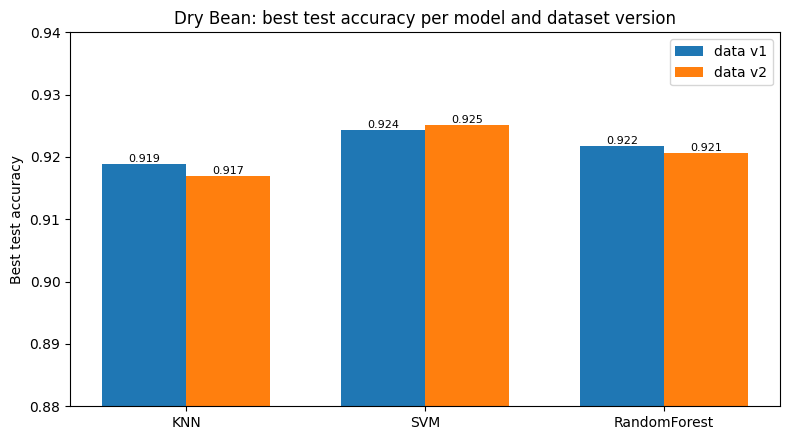

,model_family,data_version,test_accuracy,f1_score
10,KNN,v1,0.9188,0.9190
4,KNN,v2,0.9169,0.9171
6,RandomForest,v1,0.9218,0.9217
0,RandomForest,v2,0.9206,0.9205
8,SVM,v1,0.9243,0.9243
2,SVM,v2,0.9251,0.9251


In [8]:
best = table.loc[table.groupby(["model_family","data_version"]).test_accuracy.idxmax()]
fams = ["KNN","SVM","RandomForest"]; w = .35
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, v in enumerate(["v1","v2"]):
    vals = [best[(best.model_family==f)&(best.data_version==v)].test_accuracy.iloc[0] for f in fams]
    b = ax.bar([x+i*w for x in range(3)], vals, w, label=f"data {v}"); ax.bar_label(b, fmt="%.3f", fontsize=8)
ax.set_xticks([x+w/2 for x in range(3)], fams); ax.set_ylim(.88, .94); ax.set_ylabel("Best test accuracy"); ax.legend()
ax.set_title("Dry Bean: best test accuracy per model and dataset version")
fig.tight_layout(); fig.savefig(RUN/"img/model_comparison.png", dpi=150); plt.show()
best[["model_family","data_version","test_accuracy","f1_score"]].round(4)

## 5. Feast feature store
One feature definition serves both **training** (point-in-time correct offline retrieval) and **inference** (low-latency online lookup), which prevents train/serve skew.

In [9]:
from datetime import timedelta, datetime, timezone
from feast import Entity, FeatureStore, FeatureView, Field, FileSource
from feast.types import Float64

repo = RUN/"feature_repo"; (repo/"data").mkdir(parents=True, exist_ok=True)
fdf = v2.copy(); fdf.insert(0, "bean_id", range(len(fdf)))
now = datetime.now(timezone.utc)
fdf["event_timestamp"] = pd.Timestamp(now - timedelta(days=1))
fdf.to_parquet(repo/"data/beans.parquet", index=False)
(repo/"feature_store.yaml").write_text("""project: dry_bean
registry: data/registry.db
provider: local
online_store:
  type: sqlite
  path: data/online_store.db
entity_key_serialization_version: 3
""")

bean = Entity(name="bean", join_keys=["bean_id"])
src = FileSource(path=str((repo/"data/beans.parquet").resolve()), timestamp_field="event_timestamp")
bean_features = FeatureView(name="bean_features", entities=[bean], ttl=timedelta(days=365), source=src,
    schema=[Field(name="Area", dtype=Float64), Field(name="AspectRation", dtype=Float64), Field(name="ShapeFactor1", dtype=Float64)])

fs = FeatureStore(str(repo))
fs.apply([bean, bean_features])
fs.materialize(start_date=now - timedelta(days=3), end_date=now)   # load latest values into the online store
print("registered:", [fv.name for fv in fs.list_feature_views()])

C:\Users\Chris corda\AppData\Local\Temp\ipykernel_12804\3516145155.py:19: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'bean'.
  bean = Entity(name="bean", join_keys=["bean_id"])


Materializing 1 feature views from 2026-09-30 17:49:33+00:00 to 2026-10-03 17:49:33+00:00 into the sqlite online store.

bean_features:


registered: ['bean_features']


In [10]:
feats = ["bean_features:Area", "bean_features:AspectRation", "bean_features:ShapeFactor1"]
ent = pd.DataFrame({"bean_id": [0, 1, 2], "event_timestamp": [pd.Timestamp(now)] * 3})
print("--- offline (training) ---"); display(fs.get_historical_features(ent, feats).to_df())
print("--- online (inference) ---")
display(pd.DataFrame(fs.get_online_features(features=feats, entity_rows=[{"bean_id": i} for i in range(3)]).to_dict()))

--- offline (training) ---


,bean_id,event_timestamp,Area,AspectRation,ShapeFactor1
0,0,2026-10-03 17:49:33.171394+00:00,28395.0,1.197191,0.007332
1,1,2026-10-03 17:49:33.171394+00:00,28734.0,1.097356,0.006979
2,2,2026-10-03 17:49:33.171394+00:00,29380.0,1.209713,0.007244


--- online (inference) ---


,bean_id,ShapeFactor1,Area,AspectRation
0,0,0.007332,28395.0,1.197191
1,1,0.006979,28734.0,1.097356
2,2,0.007244,29380.0,1.209713


### Task 5A - Feast: three features, consistent training and inference
Features used from the model: **Area**, **AspectRation**, **ShapeFactor1** (registered above in the `bean_features` FeatureView, keyed by `bean_id`).

- **Training**: `get_historical_features` joins features to entity timestamps with a *point-in-time correct* lookup, so no future data leaks into training.
- **Inference**: `get_online_features` reads the latest values of the *same* definitions from a low-latency online store (SQLite here, Redis/Datastore in production).
- Because both paths share one definition and one registry, transformations are written once, which removes train/serve skew. Features are also reusable across models and discoverable via the registry.

## 6. Kubeflow pipeline
Five components: **collect -> validate -> train -> evaluate -> (quality gate) deploy**. The pipeline is compiled to KFP YAML (uploadable to Kubeflow or Vertex AI Pipelines). Since no cluster is available, the same stages are then executed locally.

In [11]:
from kfp import dsl, compiler
BASE = "python:3.11-slim"; PKGS = ["pandas", "scikit-learn", "mlflow", "joblib"]

@dsl.component(base_image=BASE, packages_to_install=PKGS)
def data_collection(dvc_rev: str, data_url: str, dataset: dsl.Output[dsl.Dataset]):
    import pandas as pd
    # on a real cluster: `dvc get <repo> data/dry_bean.csv --rev <dvc_rev>`
    pd.read_csv(data_url).to_csv(dataset.path, index=False)

@dsl.component(base_image=BASE, packages_to_install=PKGS)
def data_validation(dataset: dsl.Input[dsl.Dataset], validated: dsl.Output[dsl.Dataset]) -> bool:
    import pandas as pd
    df = pd.read_csv(dataset.path)
    assert df.isna().sum().sum() == 0, "missing values found"
    assert "Class" in df.columns and df.Class.nunique() == 7, "unexpected label set"
    assert len(df) > 10000, "too few rows"
    df.to_csv(validated.path, index=False)
    return True

@dsl.component(base_image=BASE, packages_to_install=PKGS)
def train(validated: dsl.Input[dsl.Dataset], model: dsl.Output[dsl.Model], test_set: dsl.Output[dsl.Dataset], C: float = 10.0):
    import pandas as pd, joblib
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC
    df = pd.read_csv(validated.path)
    Xtr, Xte, ytr, yte = train_test_split(df.drop(columns="Class"), df.Class, test_size=.2, stratify=df.Class, random_state=42)
    joblib.dump(make_pipeline(StandardScaler(), SVC(C=C)).fit(Xtr, ytr), model.path)
    pd.concat([Xte, yte], axis=1).to_csv(test_set.path, index=False)

@dsl.component(base_image=BASE, packages_to_install=PKGS)
def evaluate(model: dsl.Input[dsl.Model], test_set: dsl.Input[dsl.Dataset], metrics: dsl.Output[dsl.Metrics], threshold: float = 0.90) -> bool:
    import pandas as pd, joblib
    from sklearn.metrics import accuracy_score, f1_score
    df = pd.read_csv(test_set.path); m = joblib.load(model.path)
    pred = m.predict(df.drop(columns="Class"))
    acc, f1 = accuracy_score(df.Class, pred), f1_score(df.Class, pred, average="weighted")
    metrics.log_metric("accuracy", acc); metrics.log_metric("f1_weighted", f1)
    return acc >= threshold

@dsl.component(base_image=BASE, packages_to_install=PKGS + ["google-cloud-aiplatform"])
def deploy(model: dsl.Input[dsl.Model], project: str, region: str):
    from google.cloud import aiplatform
    aiplatform.init(project=project, location=region)
    m = aiplatform.Model.upload(display_name="dry-bean-svm", artifact_uri=model.uri,
        serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-5:latest")
    m.deploy(machine_type="n1-standard-2", min_replica_count=1, max_replica_count=3)

@dsl.pipeline(name="dry-bean-mlops", description="Collect -> Validate -> Train -> Evaluate -> (gate) Deploy")
def dry_bean_pipeline(data_url: str, dvc_rev: str = "data-v2", project: str = "my-gcp-project", region: str = "us-central1"):
    c = data_collection(dvc_rev=dvc_rev, data_url=data_url)
    v = data_validation(dataset=c.outputs["dataset"])
    t = train(validated=v.outputs["validated"]); t.after(v)
    e = evaluate(model=t.outputs["model"], test_set=t.outputs["test_set"])
    with dsl.If(e.outputs["Output"] == True):   # quality gate
        deploy(model=t.outputs["model"], project=project, region=region)

compiler.Compiler().compile(dry_bean_pipeline, str(RUN/"dry_bean_pipeline.yaml"))
print("compiled ->", RUN/"dry_bean_pipeline.yaml")

compiled -> nb_run\dry_bean_pipeline.yaml


In [12]:
# Local simulation of the same 5 DAG stages
from sklearn.metrics import f1_score
def stage(n, name): print(f"[{time.strftime('%H:%M:%S')}] stage {n}/5 {name}")

stage(1, "data_collection"); df = pd.read_csv(V2); print("  rows:", len(df))
stage(2, "data_validation")
assert df.isna().sum().sum() == 0 and df.Class.nunique() == 7 and len(df) > 10000; print("  checks passed")
stage(3, "train")
Xtr, Xte, ytr, yte = train_test_split(df.drop(columns="Class"), df.Class, test_size=.2, stratify=df.Class, random_state=42)
final = make_pipeline(StandardScaler(), SVC(C=10)).fit(Xtr, ytr); joblib.dump(final, RUN/"artifacts/model.joblib")
stage(4, "evaluate"); p = final.predict(Xte); acc = accuracy_score(yte, p)
print(f"  accuracy={acc:.4f} f1={f1_score(yte, p, average='weighted'):.4f}")
stage(5, "deploy")
print(f"  gate passed -> model promoted ({RUN/'artifacts/model.joblib'})" if acc >= .90 else "  gate FAILED -> deployment skipped")

[23:19:35] stage 1/5 data_collection
  rows: 13543
[23:19:35] stage 2/5 data_validation
  checks passed
[23:19:35] stage 3/5 train


[23:19:36] stage 4/5 evaluate


  accuracy=0.9251 f1=0.9251
[23:19:36] stage 5/5 deploy
  gate passed -> model promoted (nb_run\artifacts\model.joblib)


### How automation improves reproducibility and scalability
- **Reproducibility**: each step is a versioned, containerised component with typed inputs/outputs and pinned parameters (`dvc_rev`, `C`, `threshold`), so a run can be repeated exactly and every artifact is traceable to its run.
- **Consistency**: validation and the evaluation gate run every time, so a bad dataset or a weak model never reaches deployment by accident.
- **Scalability**: each component runs in its own pod on Kubernetes / Vertex AI Pipelines, so heavy steps (e.g. training) can get more CPU/GPU independently, run in parallel, and be re-triggered on schedule or on drift without manual work.

## 7. Deployment to Vertex AI (not executed)
Needs a GCP project with billing, so this cell only **defines** the function. To run it: `gcloud auth application-default login`, then call `deploy_to_vertex("<PROJECT>", "gs://<BUCKET>")`.

In [13]:
def deploy_to_vertex(project, bucket, region="us-central1"):
    from google.cloud import aiplatform
    # Vertex's prebuilt sklearn container expects a file named model.joblib in the artifact dir
    subprocess.run(["gsutil", "cp", str(RUN/"artifacts/model.joblib"), f"{bucket}/dry-bean/model.joblib"], check=True)
    aiplatform.init(project=project, location=region, staging_bucket=bucket)
    model = aiplatform.Model.upload(display_name="dry-bean-svm", artifact_uri=f"{bucket}/dry-bean/",
        serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-5:latest")
    endpoint = model.deploy(machine_type="n1-standard-2", min_replica_count=1, max_replica_count=3)
    print(endpoint.predict(instances=[[28395, 610.291, 208.178, 173.889, 1.197, 0.549, 0.763, 0.9889, 0.9582, 0.0073, 0.0031]]))
    # monitoring: enable model-monitoring jobs on the endpoint for feature-skew / drift alerts
    return endpoint

## 8. Lifecycle diagram

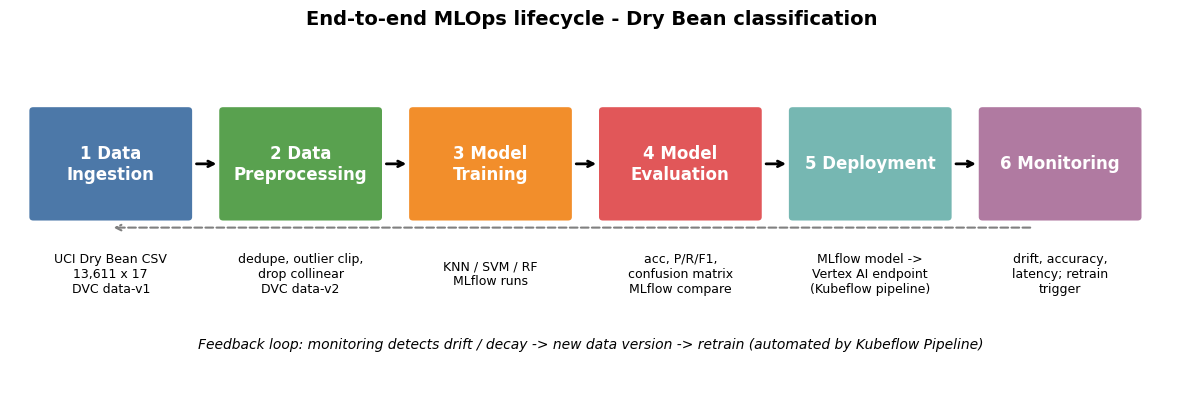

In [14]:
from matplotlib.patches import FancyBboxPatch
st = [("1 Data\nIngestion","UCI Dry Bean CSV\n13,611 x 17\nDVC data-v1"),("2 Data\nPreprocessing","dedupe, outlier clip,\ndrop collinear\nDVC data-v2"),
("3 Model\nTraining","KNN / SVM / RF\nMLflow runs"),("4 Model\nEvaluation","acc, P/R/F1,\nconfusion matrix\nMLflow compare"),
("5 Deployment","MLflow model ->\nVertex AI endpoint\n(Kubeflow pipeline)"),("6 Monitoring","drift, accuracy,\nlatency; retrain\ntrigger")]
fig, ax = plt.subplots(figsize=(15, 4.6)); ax.axis("off"); ax.set_xlim(0, 15); ax.set_ylim(0, 5)
cols = ["#4C78A8","#59A14F","#F28E2B","#E15759","#76B7B2","#B07AA1"]
for i, (a, b) in enumerate(st):
    x = .3 + i*2.45
    ax.add_patch(FancyBboxPatch((x, 2.4), 2.0, 1.5, boxstyle="round,pad=.05", fc=cols[i], ec="none"))
    ax.text(x+1, 3.15, a, ha="center", va="center", color="white", fontsize=12, fontweight="bold")
    ax.text(x+1, 1.6, b, ha="center", va="center", fontsize=9)
    if i < 5: ax.annotate("", (x+2.4, 3.15), (x+2.07, 3.15), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", (1.3, 2.25), (13.2, 2.25), arrowprops=dict(arrowstyle="->", lw=1.5, ls="--", color="gray"))
ax.text(7.5, .55, "Feedback loop: monitoring detects drift / decay -> new data version -> retrain (automated by Kubeflow Pipeline)", ha="center", fontsize=10, style="italic")
ax.set_title("End-to-end MLOps lifecycle - Dry Bean classification", fontsize=14, fontweight="bold")
fig.savefig(RUN/"img/lifecycle.png", dpi=150, bbox_inches="tight"); plt.show()

## Task 5B - Cloud platform comparison: AWS SageMaker vs Google Cloud Vertex AI
| Criterion | AWS SageMaker | Google Vertex AI |
|---|---|---|
| Services offered | Studio, Data Wrangler, Feature Store, Pipelines, Model Registry, Clarify, Model Monitor | Workbench, Feature Store, Pipelines (Kubeflow/KFP-based), Model Registry, Model Monitoring, Experiments |
| Experiment tracking | SageMaker Experiments; managed MLflow tracking server | Vertex AI Experiments and TensorBoard; MLflow can be self-hosted |
| AutoML | SageMaker Autopilot (tabular) | Vertex AI AutoML (tabular, image, text, video) |
| Deployment options | real-time, serverless, async, batch, multi-model endpoints | online endpoints with autoscaling, batch prediction, prebuilt sklearn/XGBoost/TF containers |
| Cost considerations | pay per instance-hour for notebooks, training and endpoints; serverless inference avoids idle cost; Spot training saves up to ~90% | pay per node-hour for training and endpoints plus a small pipeline run fee; AutoML priced per training hour; free-tier credits for new accounts |

**Choice for this project: Vertex AI.** Kubeflow Pipelines (used in section 6) compile directly to Vertex AI Pipelines, and the prebuilt sklearn serving container accepts our `model.joblib` unchanged (section 7).

### Deployment status
The Vertex AI deployment code is provided but **was not executed**: it needs a GCP project with billing enabled. Everything else (MLflow, DVC, Feast, the compiled KFP pipeline and its local run) was executed in this notebook.